In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

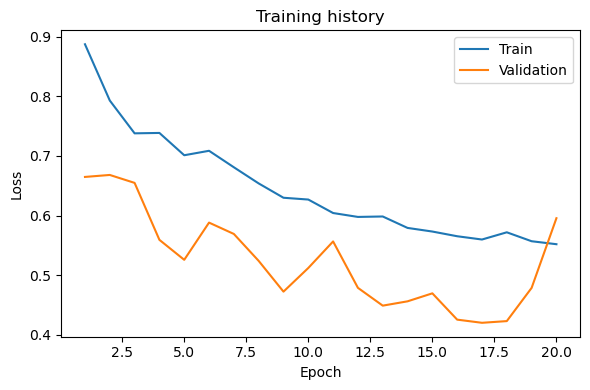

In [3]:
# loss history
hist = pd.read_csv("../outputs/unet_t_elev_urban_loss_history.csv")

plt.figure(figsize=(6, 4))
plt.plot(hist["epoch"], hist["train_loss"], label="Train")
plt.plot(hist["epoch"], hist["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# test set
ds_test = xr.open_dataset("../.data/downscaling_splits/test_norm.nc")

# predictions
ds_pred = xr.open_dataset("../outputs/test_predictions_unet_t_elev_urban.nc")

print(ds_test)
print(ds_pred)

<xarray.Dataset> Size: 552MB
Dimensions:             (time: 368, lat_coarse: 39, lon_coarse: 51, lat: 240,
                         lon: 311)
Coordinates:
  * time                (time) datetime64[ns] 3kB 2022-06-01 ... 2025-08-31
  * lat_coarse          (lat_coarse) float64 312B 46.75 46.5 ... 37.5 37.25
  * lon_coarse          (lon_coarse) float64 408B -79.75 -79.5 ... -67.5 -67.25
  * lat                 (lat) float64 2kB 46.98 46.94 46.9 ... 37.11 37.07 37.03
  * lon                 (lon) float64 2kB -79.97 -79.93 -79.89 ... -67.1 -67.06
Data variables:
    tmax_lowres         (time, lat_coarse, lon_coarse) float32 3MB ...
    tmax_highres        (time, lat, lon) float32 110MB ...
    valid_mask          (lat, lon) int8 75kB ...
    tmax_lowres_interp  (time, lat, lon) float32 110MB ...
    tmax_residual       (time, lat, lon) float32 110MB ...
    x_norm              (time, lat, lon) float32 110MB ...
    y_norm              (time, lat, lon) float32 110MB ...
Attributes:
    descr

In [6]:
# adjust variable names here if needed
common_time = ds_pred["time"]

# choose the right variable names based on your files
truth = ds_test["tmax_highres"].sel(time=common_time)
interp = ds_test["tmax_lowres_interp"].sel(time=common_time)
unet = ds_pred["pred_tmax_highres"].sel(time=common_time)

mask = ds_test["valid_mask"].astype(bool)

print(truth.shape, interp.shape, unet.shape)

(368, 240, 311) (368, 240, 311) (368, 240, 311)


In [7]:
def overall_rmse(pred, truth, mask):
    mask3d = np.broadcast_to(mask.values, truth.shape)
    err2 = (pred.values - truth.values) ** 2
    err2 = np.where(mask3d, err2, np.nan)
    return np.sqrt(np.nanmean(err2))

def overall_mae(pred, truth, mask):
    mask3d = np.broadcast_to(mask.values, truth.shape)
    err = np.abs(pred.values - truth.values)
    err = np.where(mask3d, err, np.nan)
    return np.nanmean(err)

print("Interpolation RMSE:", overall_rmse(interp, truth, mask))
print("Interpolation MAE :", overall_mae(interp, truth, mask))
print("U-Net with Elev. & Urban RMSE        :", overall_rmse(unet, truth, mask))
print("U-Net with Elev. & Urban MAE         :", overall_mae(unet, truth, mask))

Interpolation RMSE: 1.5690082
Interpolation MAE : 1.1934239
U-Net with Elev. & Urban RMSE        : 1.1610773
U-Net with Elev. & Urban MAE         : 0.8905442


In [8]:
# daily RMSE for interpolation and U-Net
mask3d = np.broadcast_to(mask.values, truth.shape)

interp_err2 = (interp.values - truth.values) ** 2
interp_err2 = np.where(mask3d, interp_err2, np.nan)
daily_interp_rmse = np.sqrt(np.nanmean(interp_err2, axis=(1, 2)))

unet_err2 = (unet.values - truth.values) ** 2
unet_err2 = np.where(mask3d, unet_err2, np.nan)
daily_unet_rmse = np.sqrt(np.nanmean(unet_err2, axis=(1, 2)))
truth_masked = truth.where(mask)
daily_truth_mean = truth_masked.mean(dim=("lat", "lon"))


In [9]:
# %%
def daily_spatial_correlation(pred, truth, mask):
    mask2d = mask.values.astype(bool)
    corrs = []

    for t in range(truth.sizes["time"]):
        x = pred.isel(time=t).values
        y = truth.isel(time=t).values

        valid = mask2d & np.isfinite(x) & np.isfinite(y)

        if np.sum(valid) < 2:
            corrs.append(np.nan)
            continue

        x_valid = x[valid]
        y_valid = y[valid]

        # avoid division by zero if one field is constant
        if np.std(x_valid) == 0 or np.std(y_valid) == 0:
            corrs.append(np.nan)
        else:
            corrs.append(np.corrcoef(x_valid, y_valid)[0, 1])

    return np.array(corrs)


def daily_std_ratio(pred, truth, mask):
    """
    Spatial std(pred) / std(truth) for each day over valid grid cells.
    If ratio < 1: prediction is too smooth
    If ratio > 1: prediction is too variable
    """
    mask2d = mask.values.astype(bool)
    ratios = []

    for t in range(truth.sizes["time"]):
        x = pred.isel(time=t).values
        y = truth.isel(time=t).values

        valid = mask2d & np.isfinite(x) & np.isfinite(y)

        if np.sum(valid) < 2:
            ratios.append(np.nan)
            continue

        x_valid = x[valid]
        y_valid = y[valid]

        y_std = np.std(y_valid)
        if y_std == 0:
            ratios.append(np.nan)
        else:
            ratios.append(np.std(x_valid) / y_std)

    return np.array(ratios)

In [10]:
# %%
daily_interp_corr = daily_spatial_correlation(interp, truth, mask)
daily_unet_corr = daily_spatial_correlation(unet, truth, mask)

daily_interp_std_ratio = daily_std_ratio(interp, truth, mask)
daily_unet_std_ratio = daily_std_ratio(unet, truth, mask)

print("Mean daily spatial correlation")
print("  Interp:", np.nanmean(daily_interp_corr))
print("  U-Net with Elev. & Urban :", np.nanmean(daily_unet_corr))

print("Mean daily std ratio")
print("  Interp:", np.nanmean(daily_interp_std_ratio))
print("  U-Net with Elev. & Urban :", np.nanmean(daily_unet_std_ratio))

Mean daily spatial correlation
  Interp: 0.8476813212190765
  U-Net with Elev. & Urban : 0.9139658204364594
Mean daily std ratio
  Interp: 1.0520313
  U-Net with Elev. & Urban : 0.97459066


In [11]:
import numpy as np

n_days = len(common_time)
n_top = max(1, int(np.ceil(0.05 * n_days)))

best5_idxs = np.argsort(daily_unet_rmse)[:n_top]
worst5_idxs = np.argsort(daily_unet_rmse)[-n_top:]
hottest5_idxs = np.argsort(daily_truth_mean.values)[-n_top:]

print("Number of days in 10% group:", n_top)
print("Best 10% example dates:", common_time.values[best5_idxs[:5]])
print("Worst 10% example dates:", common_time.values[worst5_idxs[:5]])
print("Hottest 10% example dates:", common_time.values[hottest5_idxs[:5]])

Number of days in 10% group: 19
Best 10% example dates: ['2024-07-03T00:00:00.000000000' '2024-06-13T00:00:00.000000000'
 '2025-08-28T00:00:00.000000000' '2024-06-01T00:00:00.000000000'
 '2024-08-24T00:00:00.000000000']
Worst 10% example dates: ['2025-08-01T00:00:00.000000000' '2024-08-06T00:00:00.000000000'
 '2022-07-09T00:00:00.000000000' '2022-08-09T00:00:00.000000000'
 '2025-08-13T00:00:00.000000000']
Hottest 10% example dates: ['2025-07-16T00:00:00.000000000' '2024-07-14T00:00:00.000000000'
 '2022-08-04T00:00:00.000000000' '2023-07-06T00:00:00.000000000'
 '2025-07-30T00:00:00.000000000']


In [12]:
def plot_composite(idxs, title):
    truth_comp = truth.isel(time=idxs).mean(dim="time")
    interp_comp = interp.isel(time=idxs).mean(dim="time")
    unet_comp = unet.isel(time=idxs).mean(dim="time")

    err_interp = interp_comp - truth_comp
    err_unet = unet_comp - truth_comp
    improve = np.abs(err_interp) - np.abs(err_unet)

    vmin = np.nanmin([
        truth_comp.where(mask).values,
        interp_comp.where(mask).values,
        unet_comp.where(mask).values,
    ])
    vmax = np.nanmax([
        truth_comp.where(mask).values,
        interp_comp.where(mask).values,
        unet_comp.where(mask).values,
    ])

    emax = np.nanmax(np.abs([
        err_interp.where(mask).values,
        err_unet.where(mask).values,
    ]))
    imax = np.nanmax(np.abs(improve.where(mask).values))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

    panels = [
        (truth_comp.where(mask), "Truth composite", "viridis", vmin, vmax),
        (interp_comp.where(mask), "Interpolation composite", "viridis", vmin, vmax),
        (unet_comp.where(mask), "U-Net with Elev. & Urban composite", "viridis", vmin, vmax),
        (err_interp.where(mask), "Interp - Truth", "RdBu_r", -emax, emax),
        (err_unet.where(mask), "U-Net with Elev. & Urban - Truth", "RdBu_r", -emax, emax),
        (improve.where(mask), "Abs error improvement\n(positive = U-Net with Elev. & Urban better)", "RdBu_r", -imax, imax),
    ]

    for ax, (da, panel_title, cmap, v0, v1) in zip(axes.flat, panels):
        pcm = ax.pcolormesh(
            da["lon"], da["lat"], da.values,
            shading="auto", cmap=cmap, vmin=v0, vmax=v1
        )
        ax.set_title(panel_title)
        ax.set_xlabel("Lon")
        ax.set_ylabel("Lat")
        plt.colorbar(pcm, ax=ax, shrink=0.8)

    fig.suptitle(title, fontsize=14)
    plt.show()

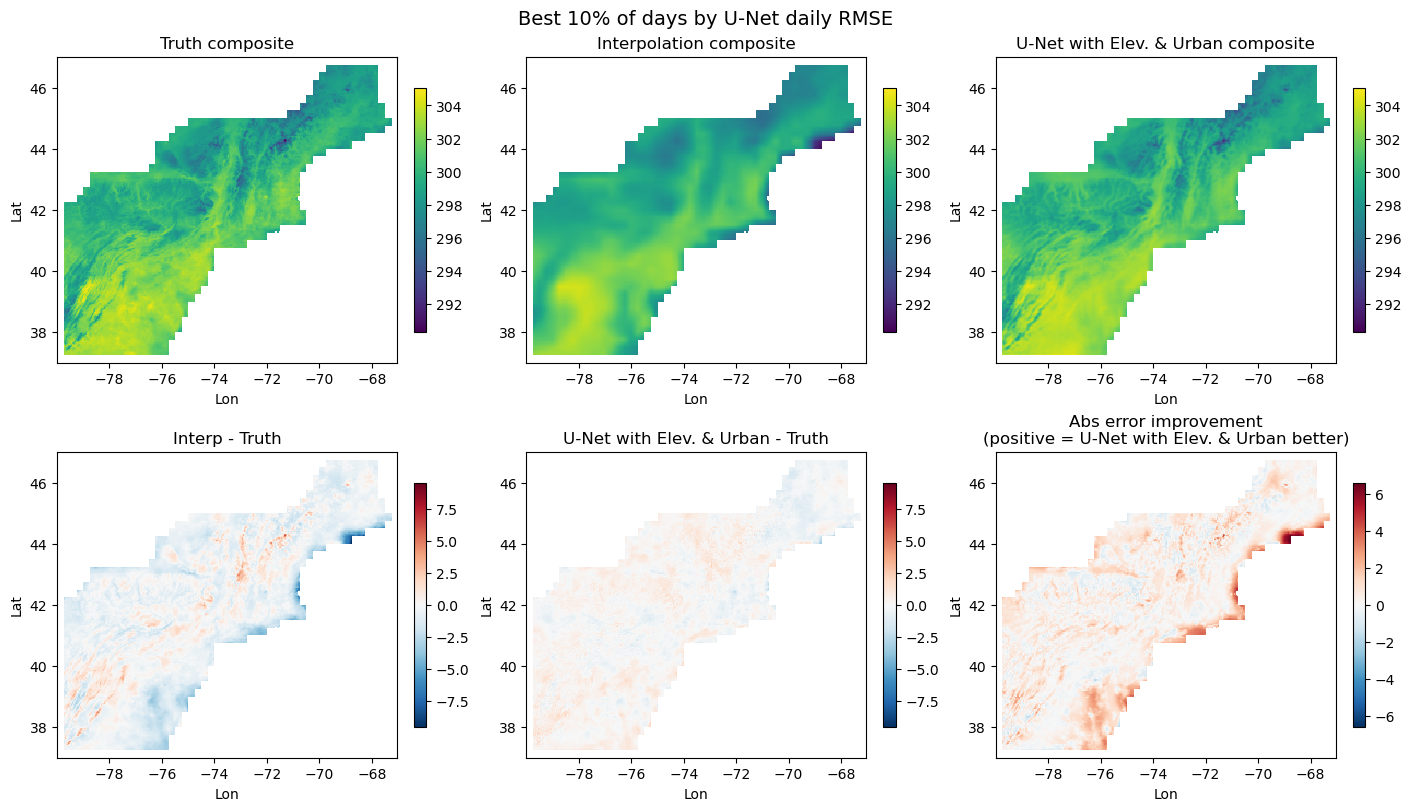

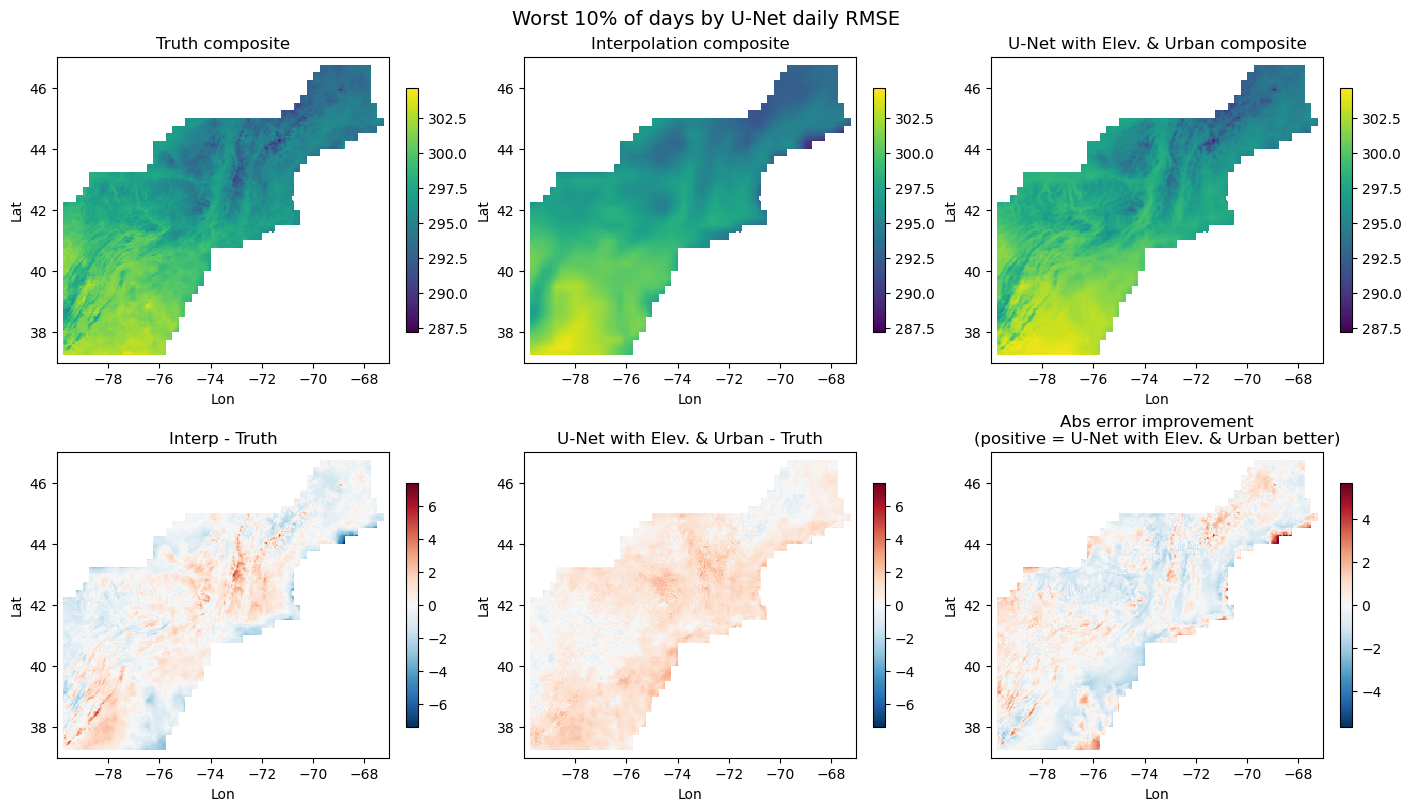

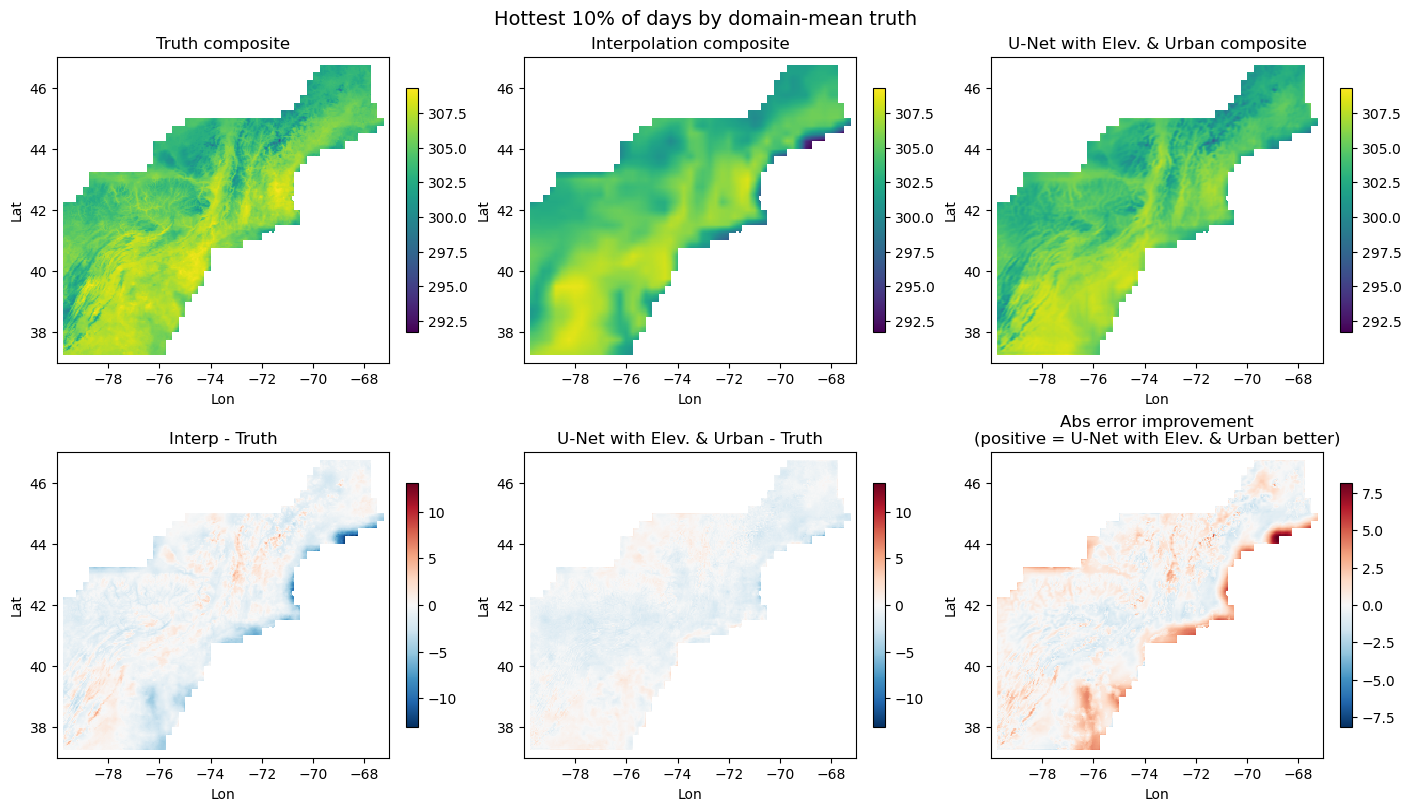

In [13]:
plot_composite(best5_idxs, "Best 10% of days by U-Net daily RMSE")
plot_composite(worst5_idxs, "Worst 10% of days by U-Net daily RMSE")
plot_composite(hottest5_idxs, "Hottest 10% of days by domain-mean truth")

In [14]:
print("Mean daily RMSE over best 10% days")
print("  Interp:", np.nanmean(daily_interp_rmse[best5_idxs]))
print("  U-Net with Elev. & Urban :", np.nanmean(daily_unet_rmse[best5_idxs]))

print("Mean daily RMSE over worst 10% days")
print("  Interp:", np.nanmean(daily_interp_rmse[worst5_idxs]))
print("  U-Net with Elev. & Urban :", np.nanmean(daily_unet_rmse[worst5_idxs]))

print("Mean daily RMSE over hottest 10% days")
print("  Interp:", np.nanmean(daily_interp_rmse[hottest5_idxs]))
print("  U-Net with Elev. & Urban :", np.nanmean(daily_unet_rmse[hottest5_idxs]))

Mean daily RMSE over best 10% days
  Interp: 1.3646587
  U-Net with Elev. & Urban : 0.78258955
Mean daily RMSE over worst 10% days
  Interp: 1.8896824
  U-Net with Elev. & Urban : 1.9724579
Mean daily RMSE over hottest 10% days
  Interp: 1.7693771
  U-Net with Elev. & Urban : 1.1940869


In [17]:
# %%
print("Mean daily spatial correlation over best 10% days")
print("  Interp:", np.nanmean(daily_interp_corr[best5_idxs]))
print("  U-Net with Elev. & Urban :", np.nanmean(daily_unet_corr[best5_idxs]))

print("Mean daily spatial correlation over worst 10% days")
print("  Interp:", np.nanmean(daily_interp_corr[worst5_idxs]))
print("  U-Net with Elev. & Urban :", np.nanmean(daily_unet_corr[worst5_idxs]))

print("Mean daily spatial correlation over hottest 10% days")
print("  Interp:", np.nanmean(daily_interp_corr[hottest5_idxs]))
print("  U-Net with Elev. & Urban :", np.nanmean(daily_unet_corr[hottest5_idxs]))

print("Mean daily std ratio over best 10% days")
print("  Interp:", np.nanmean(daily_interp_std_ratio[best5_idxs]))
print("  U-Net with Elev. & Urban :", np.nanmean(daily_unet_std_ratio[best5_idxs]))

print("Mean daily std ratio over worst 10% days")
print("  Interp:", np.nanmean(daily_interp_std_ratio[worst5_idxs]))
print("  U-Net with Elev. & Urban :", np.nanmean(daily_unet_std_ratio[worst5_idxs]))

print("Mean daily std ratio over hottest 10% days")
print("  Interp:", np.nanmean(daily_interp_std_ratio[hottest5_idxs]))
print("  U-Net with Elev. & Urban :", np.nanmean(daily_unet_std_ratio[hottest5_idxs]))

Mean daily spatial correlation over best 10% days
  Interp: 0.8221586859502191
  U-Net with Elev. & Urban : 0.9309734998292283
Mean daily spatial correlation over worst 10% days
  Interp: 0.8667521624417084
  U-Net with Elev. & Urban : 0.8833343844779573
Mean daily spatial correlation over hottest 10% days
  Interp: 0.7621592159511482
  U-Net with Elev. & Urban : 0.872121295139362
Mean daily std ratio over best 10% days
  Interp: 1.038974
  U-Net with Elev. & Urban : 0.9804298
Mean daily std ratio over worst 10% days
  Interp: 0.8999848
  U-Net with Elev. & Urban : 0.84856564
Mean daily std ratio over hottest 10% days
  Interp: 1.1627904
  U-Net with Elev. & Urban : 0.9502533


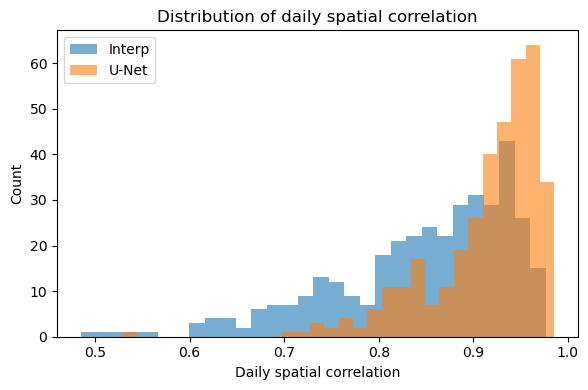

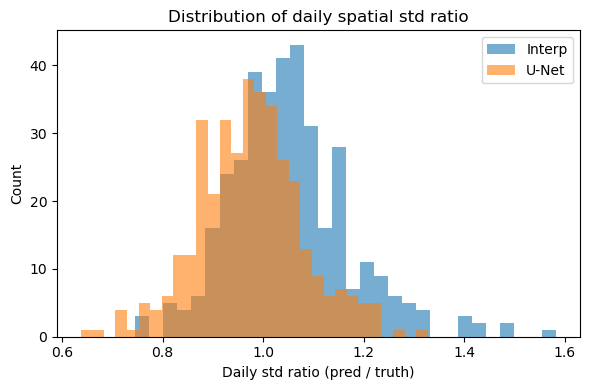

In [18]:
# %%
plt.figure(figsize=(6, 4))
plt.hist(daily_interp_corr, bins=30, alpha=0.6, label="Interp")
plt.hist(daily_unet_corr, bins=30, alpha=0.6, label="U-Net")
plt.xlabel("Daily spatial correlation")
plt.ylabel("Count")
plt.title("Distribution of daily spatial correlation")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(daily_interp_std_ratio, bins=30, alpha=0.6, label="Interp")
plt.hist(daily_unet_std_ratio, bins=30, alpha=0.6, label="U-Net")
plt.xlabel("Daily std ratio (pred / truth)")
plt.ylabel("Count")
plt.title("Distribution of daily spatial std ratio")
plt.legend()
plt.tight_layout()
plt.show()